In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# CONFIGURACIÓN

INPUT_FILE = "dataset_1d_variable_models_variable_ab2.npz"
OUTPUT_FILE = "dataset_denoising_gaussian.npz"

# niveles de ruido relativo
NOISE_LEVELS = [0.01, 0.03, 0.05, 0.10]   # 1%, 3%, 5%, 10%
N_REALIZATIONS_PER_LEVEL = 1              # cuántas curvas ruidosas crear por nivel

In [34]:
# CARGAR DATASET ORIGINAL

data = np.load(INPUT_FILE)

rho_clean_base = data["rho_app"]          # curvas limpias
ab2_base = data["ab2"]
n_ab2_base = data["n_ab2"]

# metadatos opcionales
resistivities_base = data["resistivities"] if "resistivities" in data else None
thicknesses_base = data["thicknesses"] if "thicknesses" in data else None
depths_base = data["depths"] if "depths" in data else None
n_layers_base = data["n_layers"] if "n_layers" in data else None
total_depth_base = data["total_depth"] if "total_depth" in data else None

n_models, max_points = rho_clean_base.shape

In [35]:
# FUNCIÓN PARA AÑADIR RUIDO GAUSSIANO

def add_gaussian_noise(curve, noise_level):
    """
    noise_level = ruido relativo
    noisy = clean + N(0, noise_level * clean)
    """
    noise = np.random.normal(0.0, noise_level, size=curve.shape)
    noisy_curve = curve * (1.0 + noise)

    # evitar valores no físicos
    noisy_curve = np.clip(noisy_curve, 1e-8, None)
    return noisy_curve

In [36]:
# CREAR DATASET DE DENOISING

clean_list = []
noisy_list = []
ab2_list = []
n_ab2_list = []
noise_level_list = []
source_index_list = []

resistivities_list = []
thicknesses_list = []
depths_list = []
n_layers_list = []
total_depth_list = []

for i in range(n_models):
    npts = n_ab2_base[i]

    clean_curve = rho_clean_base[i, :npts]
    ab2_curve = ab2_base[i, :npts]

    for level in NOISE_LEVELS:
        for _ in range(N_REALIZATIONS_PER_LEVEL):
            noisy_curve = add_gaussian_noise(clean_curve, level)

            clean_pad = np.full(max_points, np.nan, dtype=np.float32)
            noisy_pad = np.full(max_points, np.nan, dtype=np.float32)
            ab2_pad = np.full(max_points, np.nan, dtype=np.float32)

            clean_pad[:npts] = clean_curve
            noisy_pad[:npts] = noisy_curve
            ab2_pad[:npts] = ab2_curve

            clean_list.append(clean_pad)
            noisy_list.append(noisy_pad)
            ab2_list.append(ab2_pad)
            n_ab2_list.append(npts)
            noise_level_list.append(level)
            source_index_list.append(i)

            if resistivities_base is not None:
                resistivities_list.append(resistivities_base[i])
            if thicknesses_base is not None:
                thicknesses_list.append(thicknesses_base[i])
            if depths_base is not None:
                depths_list.append(depths_base[i])
            if n_layers_base is not None:
                n_layers_list.append(n_layers_base[i])
            if total_depth_base is not None:
                total_depth_list.append(total_depth_base[i])


In [37]:
# CONVERTIR A ARRAYS

clean_arr = np.array(clean_list, dtype=np.float32)
noisy_arr = np.array(noisy_list, dtype=np.float32)
ab2_arr = np.array(ab2_list, dtype=np.float32)

n_ab2_arr = np.array(n_ab2_list, dtype=np.int32)
noise_level_arr = np.array(noise_level_list, dtype=np.float32)
source_index_arr = np.array(source_index_list, dtype=np.int32)

save_dict = {
    "clean_curves": clean_arr,
    "noisy_curves": noisy_arr,
    "ab2": ab2_arr,
    "n_ab2": n_ab2_arr,
    "noise_level": noise_level_arr,
    "source_index": source_index_arr
}

if resistivities_base is not None:
    save_dict["resistivities"] = np.array(resistivities_list, dtype=np.float32)
if thicknesses_base is not None:
    save_dict["thicknesses"] = np.array(thicknesses_list, dtype=np.float32)
if depths_base is not None:
    save_dict["depths"] = np.array(depths_list, dtype=np.float32)
if n_layers_base is not None:
    save_dict["n_layers"] = np.array(n_layers_list, dtype=np.int32)
if total_depth_base is not None:
    save_dict["total_depth"] = np.array(total_depth_list, dtype=np.float32)

In [38]:
# GUARDAR NUEVO DATASET

np.savez_compressed(OUTPUT_FILE, **save_dict)

print(f"Archivo guardado: {OUTPUT_FILE}")
print("Shapes:")
print("clean_curves:", clean_arr.shape)
print("noisy_curves:", noisy_arr.shape)
print("ab2         :", ab2_arr.shape)
print("n_ab2       :", n_ab2_arr.shape)
print("noise_level :", noise_level_arr.shape)

Archivo guardado: dataset_denoising_gaussian.npz
Shapes:
clean_curves: (40000, 40)
noisy_curves: (40000, 40)
ab2         : (40000, 40)
n_ab2       : (40000,)
noise_level : (40000,)


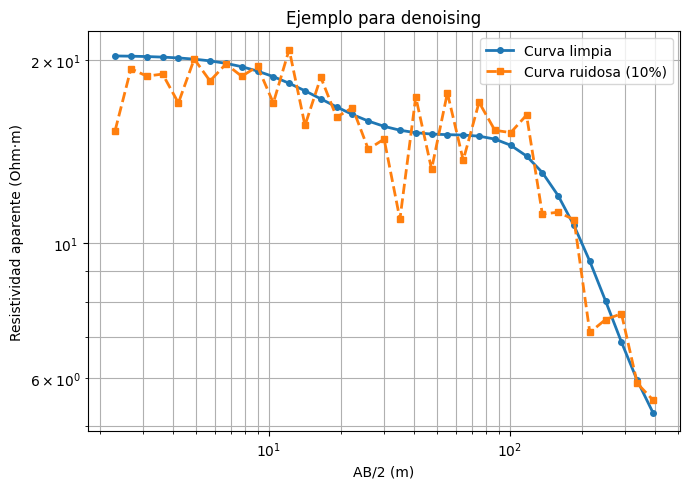

In [39]:
# GRAFICAR UN EJEMPLO

j = np.random.randint(0, len(clean_arr))

npts = n_ab2_arr[j]
ab2_ex = ab2_arr[j, :npts]
clean_ex = clean_arr[j, :npts]
noisy_ex = noisy_arr[j, :npts]
level_ex = noise_level_arr[j]

plt.figure(figsize=(7, 5))
plt.loglog(ab2_ex, clean_ex, 'o-', label='Curva limpia', linewidth=2, markersize=4)
plt.loglog(ab2_ex, noisy_ex, 's--', label=f'Curva ruidosa ({level_ex*100:.0f}%)', linewidth=2, markersize=4)
plt.xlabel("AB/2 (m)")
plt.ylabel("Resistividad aparente (Ohm·m)")
plt.title("Ejemplo para denoising")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()